# Exercises week 36

**FYS-STK3155/4155, fall 2026 — deadline Friday September 4 at midnight.**

The aim this week is that you own the two central results of Monday's lecture
— the statistics of the OLS estimator and the bias-variance decomposition,
Eq. (2.52) of the book — and the two resampling tools, the bootstrap and
$k$-fold cross-validation. The code you developed in the Tuesday session
(`week36tuesday.ipynb`) is meant to be reused here, and everything in this set
is directly reusable in Project 1.

Reading: Chapter 2, Sections 2.3–2.12 of the book; Hastie et al., Sections
7.1–7.5, 7.10 and 7.11.

## Exercise 1: Analytical exercises — the statistics of the OLS estimator

Assume the data are generated by the linear model of Eq. (2.37),
$\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$,
with independent noise $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ and a
fixed (non-stochastic) design matrix $\boldsymbol{X}$ of dimension $n \times p$.

**1a)** Show that the expectation value and variance of a single output are
(Eq. (2.39))

$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\,\boldsymbol{\theta},
\qquad
\mathrm{Var}(y_i) = \sigma^2 .
$$

**1b)** Show that the OLS estimator is unbiased,
$\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta}$ (Eq. (2.45)), and
derive its variance (Eq. (2.47)),

$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \sigma^2\left(\boldsymbol{X}^T\boldsymbol{X}\right)^{-1}.
$$

*Hint:* use
$\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T] = \boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T + \sigma^2\boldsymbol{I}_{nn}$.

**1c)** Optional: Explain how the diagonal elements of
$\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ give a confidence interval for
the coefficient $\theta_j$ (Eq. (2.48)), and why in practice $\sigma^2$ is
replaced by
$\hat{\sigma}^2 = \|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2/(n-p)$.
Where does the $n-p$ come from? (Think of Bessel's correction, Eq. (2.28).)

### Solution to Exercise 1

**1a) Mean and variance of $y_i$**

Row $i$ of the model $\boldsymbol{y}=\boldsymbol{X}\boldsymbol{\theta}+\boldsymbol{\varepsilon}$ reads
$$
y_i = \boldsymbol{X}_{i,*}\boldsymbol{\theta} + \varepsilon_i .
$$
Since $\boldsymbol{X}$ is fixed (non-stochastic), $\boldsymbol{X}_{i,*}\boldsymbol{\theta}$ is a constant, and by linearity of expectation
$$
\mathbb{E}[y_i] = \boldsymbol{X}_{i,*}\boldsymbol{\theta} + \mathbb{E}[\varepsilon_i] = \boldsymbol{X}_{i,*}\boldsymbol{\theta},
$$
using $\mathbb{E}[\varepsilon_i]=0$. Because a constant has zero variance and $\varepsilon_i$ is the only random piece,
$$
\mathrm{Var}(y_i) = \mathrm{Var}(\boldsymbol{X}_{i,*}\boldsymbol{\theta}) + \mathrm{Var}(\varepsilon_i) = 0 + \sigma^2 = \sigma^2 .
$$

**1b) The OLS estimator is unbiased, with variance $\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$**

Insert the model into the OLS formula $\hat{\boldsymbol{\theta}}=(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{y}$:
$$
\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\theta}+\boldsymbol{\varepsilon})
= \boldsymbol{\theta} + \underbrace{(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T}_{\boldsymbol{A}}\,\boldsymbol{\varepsilon}.
$$

*Unbiasedness.* Taking the expectation (again $\boldsymbol{X}$, hence $\boldsymbol{A}$, is non-random):
$$
\mathbb{E}[\hat{\boldsymbol{\theta}}] = \boldsymbol{\theta} + \boldsymbol{A}\,\mathbb{E}[\boldsymbol{\varepsilon}] = \boldsymbol{\theta}.
$$

*Variance, via the hint.* With $\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T]=\boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T+\sigma^2\boldsymbol{I}_{nn}$,
$$
\mathbb{E}[\hat{\boldsymbol{\theta}}\hat{\boldsymbol{\theta}}^T]
= \boldsymbol{A}\,\mathbb{E}[\boldsymbol{y}\boldsymbol{y}^T]\,\boldsymbol{A}^T
= \boldsymbol{A}\big(\boldsymbol{X}\boldsymbol{\theta}\boldsymbol{\theta}^T\boldsymbol{X}^T+\sigma^2\boldsymbol{I}\big)\boldsymbol{A}^T .
$$
Since $\boldsymbol{A}\boldsymbol{X}=(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{X}=\boldsymbol{I}$, the first term collapses to $\boldsymbol{\theta}\boldsymbol{\theta}^T$, and using $\boldsymbol{A}\boldsymbol{A}^T=(\boldsymbol{X}^T\boldsymbol{X})^{-1}\boldsymbol{X}^T\boldsymbol{X}(\boldsymbol{X}^T\boldsymbol{X})^{-1}=(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ (using symmetry of $(\boldsymbol{X}^T\boldsymbol{X})^{-1}$),
$$
\mathbb{E}[\hat{\boldsymbol{\theta}}\hat{\boldsymbol{\theta}}^T] = \boldsymbol{\theta}\boldsymbol{\theta}^T + \sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}.
$$
Hence
$$
\mathrm{Var}(\hat{\boldsymbol{\theta}}) = \mathbb{E}[\hat{\boldsymbol{\theta}}\hat{\boldsymbol{\theta}}^T] - \mathbb{E}[\hat{\boldsymbol{\theta}}]\,\mathbb{E}[\hat{\boldsymbol{\theta}}]^T
= \boldsymbol{\theta}\boldsymbol{\theta}^T+\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1} - \boldsymbol{\theta}\boldsymbol{\theta}^T = \sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}.
$$
(Equivalently, directly: $\mathrm{Var}(\hat{\boldsymbol{\theta}})=\mathrm{Var}(\boldsymbol{A}\boldsymbol{\varepsilon})=\boldsymbol{A}\,\mathrm{Var}(\boldsymbol{\varepsilon})\,\boldsymbol{A}^T=\sigma^2\boldsymbol{A}\boldsymbol{A}^T=\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$, same computation, no need for the hint.)

**1c) Confidence intervals and the $n-p$ correction (optional)**

The $j$-th diagonal entry of $\mathrm{Var}(\hat{\boldsymbol{\theta}})=\sigma^2(\boldsymbol{X}^T\boldsymbol{X})^{-1}$ is exactly $\mathrm{Var}(\hat\theta_j)$, since the diagonal of a covariance matrix holds the marginal variances of its components. So the standard error of $\hat\theta_j$ is
$$
\mathrm{SE}(\hat\theta_j) = \sigma\sqrt{\big[(\boldsymbol{X}^T\boldsymbol{X})^{-1}\big]_{jj}} .
$$
Under Gaussian noise $\hat{\boldsymbol{\theta}}$ is itself Gaussian (a linear map $\boldsymbol{A}\boldsymbol{\varepsilon}$ of Gaussian $\boldsymbol{\varepsilon}$, plus the constant $\boldsymbol{\theta}$), so $\hat\theta_j\sim\mathcal N(\theta_j,\mathrm{SE}(\hat\theta_j)^2)$ and a $95\%$ confidence interval is
$$
\hat\theta_j \pm 1.96\,\mathrm{SE}(\hat\theta_j),
$$
which is Eq. (2.48) (with a $t_{n-p,\,0.975}$ quantile replacing $1.96$ once $\sigma$ is estimated from the data, see below, to account for the extra uncertainty in $\hat\sigma$).

In practice $\sigma^2$ is unknown and is replaced by
$$
\hat\sigma^2 = \frac{\|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2}{n-p}.
$$
The division by $n-p$ rather than $n$ is exactly Bessel's correction, Eq. (2.28), generalised from estimating one mean to estimating $p$ regression coefficients: fitting $\hat{\boldsymbol{\theta}}$ by least squares forces the residual vector $\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}$ to be orthogonal to every column of $\boldsymbol{X}$ (the normal equations $\boldsymbol{X}^T(\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}})=\boldsymbol{0}$), which pins down $p$ linear combinations of the residuals. This leaves only $n-p$ "free" degrees of freedom in the residual vector, so the sum of squared residuals systematically undershoots $n\sigma^2$ by $p\sigma^2$ on average — one can show $\mathbb{E}\big[\|\boldsymbol{y}-\boldsymbol{X}\hat{\boldsymbol{\theta}}\|_2^2\big]=(n-p)\sigma^2$. Dividing by $n-p$ instead of $n$ exactly cancels this, so that $\hat\sigma^2$ is an unbiased estimator of $\sigma^2$, just as dividing by $n-1$ (instead of $n$) makes the sample variance unbiased when the single degree of freedom "used up" is the sample mean ($p=1$ column, a constant).

## Exercise 2: Analytical exercises — deriving the bias-variance tradeoff

Assume now, as in Section 2.10, that the true data are generated by
$\boldsymbol{y} = f(\boldsymbol{x}) + \boldsymbol{\varepsilon}$ with
$\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2)$ (Eq. (2.49)), and let
$\tilde{\boldsymbol{y}}$ be the prediction of a model fitted on a randomly
drawn training set.

**2a)** Starting from the expected squared error
$\mathbb{E}[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2]$ and adding and
subtracting $\mathbb{E}[\tilde{\boldsymbol{y}}]$, derive the decomposition of
Eq. (2.52),

$$
\mathbb{E}\left[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\right]
= \frac{1}{n}\sum_i\left(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \frac{1}{n}\sum_i\left(\tilde{y}_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\right)^2
+ \sigma^2 .
$$

Show explicitly that all three cross terms vanish, stating for each one which
assumption kills it (zero-mean noise, independence of noise and training set,
$f$ non-stochastic).

**2b)** Explain in your own words what the expectation
$\mathbb{E}[\cdot]$ runs over, and what each of the three terms means for the
polynomial-fit example of the lecture.

**2c)** In the numerical estimate (Tuesday's Case 1) the bias is computed
against $y_{\mathrm{test}}$ rather than the unknown $f$. Show that the
measured "bias" then contains $\sigma^2$, so the printed identity
`error >= bias + variance` is an inequality.

### Solution to Exercise 2

**2a) Deriving the bias-variance decomposition**

Work pointwise, at a single test point $x_i$ with $y_i = f_i + \varepsilon_i$ ($f_i = f(x_i)$ non-stochastic, $\varepsilon_i\sim\mathcal N(0,\sigma^2)$), and let $\tilde y_i$ be the model's prediction at $x_i$, random because it depends on which training set was drawn. Assume the test noise $\varepsilon_i$ is independent of the training set (so independent of $\tilde y_i$).

Add and subtract $\mathbb{E}[\tilde y_i]$:
$$
y_i - \tilde y_i = \underbrace{\big(f_i-\mathbb{E}[\tilde y_i]\big)}_{A,\ \text{constant}} + \underbrace{\big(\mathbb{E}[\tilde y_i]-\tilde y_i\big)}_{B,\ \mathbb{E}[B]=0} + \underbrace{\varepsilon_i}_{C,\ \mathbb{E}[C]=0}.
$$
Squaring and expanding,
$$
(y_i-\tilde y_i)^2 = A^2+B^2+C^2+2AB+2AC+2BC,
$$
and taking the expectation (over training-set draws *and* the test noise $\varepsilon_i$):

$$
\mathbb{E}\big[(y_i-\tilde y_i)^2\big] = A^2+\mathbb{E}[B^2]+\mathbb{E}[C^2]+2A\,\mathbb{E}[B]+2A\,\mathbb{E}[C]+2\,\mathbb{E}[BC].
$$

The three cross terms vanish, each for a different reason:

- $2A\,\mathbb{E}[B]=0$: $A=f_i-\mathbb{E}[\tilde y_i]$ is a **non-stochastic constant** (because $f$ is deterministic), and $\mathbb{E}[B]=\mathbb{E}[\mathbb{E}[\tilde y_i]-\tilde y_i]=\mathbb{E}[\tilde y_i]-\mathbb{E}[\tilde y_i]=0$ trivially, by definition of the mean.
- $2A\,\mathbb{E}[C]=0$: kills because the noise has **zero mean**, $\mathbb{E}[C]=\mathbb{E}[\varepsilon_i]=0$.
- $2\,\mathbb{E}[BC]=0$: since $\varepsilon_i$ is drawn **independently of the training set** used to produce $\tilde y_i$, $B$ and $C$ are independent, so $\mathbb{E}[BC]=\mathbb{E}[B]\,\mathbb{E}[C]=0\cdot 0=0$ (uses zero-mean noise again).

What remains is
$$
\mathbb{E}\big[(y_i-\tilde y_i)^2\big] = \big(f_i-\mathbb{E}[\tilde y_i]\big)^2 + \mathbb{E}\big[(\tilde y_i-\mathbb{E}[\tilde y_i])^2\big] + \sigma^2
= \text{Bias}^2(\tilde y_i) + \mathrm{Var}(\tilde y_i) + \sigma^2 .
$$
Averaging this identity over the $n$ test points $i=1,\dots,n$ gives exactly Eq. (2.52),
$$
\mathbb{E}\big[(\boldsymbol{y}-\tilde{\boldsymbol{y}})^2\big]
= \frac1n\sum_i\big(f_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\big)^2
+ \frac1n\sum_i\big(\tilde y_i-\mathbb{E}[\tilde{\boldsymbol{y}}]\big)^2
+ \sigma^2 .
$$

**2b) What does $\mathbb{E}[\cdot]$ run over, and what do the terms mean?**

The expectation is over repeated draws of the **training set**: imagine redrawing a fresh noisy training sample many times, fitting a model of the same type/complexity on each draw, and evaluating it at the (fixed) test point(s) $x_i$; on top of that, it also runs over the **test noise** $\varepsilon_i$ realized on the test point itself, since $y_i=f_i+\varepsilon_i$ is random too. In the lecture's polynomial-fit picture, this means: refit the degree-$d$ polynomial on many different noisy samples of the same underlying curve, and look at the spread of the resulting curves at a given $x$.

- $\text{Bias}^2$ measures how far the *average* prediction (averaged over all training-set draws) sits from the truth $f_i$. It reflects the model's structural ability to represent $f$: a low-degree polynomial cannot bend to fit the two-bump shape used in exercise 3, so it is far off *on average* — high bias, regardless of the particular training sample (**underfitting**).
- $\mathrm{Var}(\tilde y_i)$ measures how much the prediction *fluctuates* from one training-set draw to the next. A high-degree polynomial fits each particular noisy sample almost exactly, so it changes a lot depending on which points happened to land in the training set — high variance (**overfitting**).
- $\sigma^2$ is the noise variance of the data-generating process itself. It does not depend on the model at all, and is an **irreducible error floor**: even the true function $f$ predicted with zero bias and zero variance would still miss $y_i=f_i+\varepsilon_i$ by $\varepsilon_i$ on average $\sigma^2$ in squared error.

**2c) The bootstrap "bias" is measured against $y_{\mathrm{test}}$, not $f$**

In the code, "bias$^2$" at test point $i$ is computed as $\big(y_{\mathrm{test},i}-\bar{\tilde y}_i\big)^2$, where $\bar{\tilde y}_i=\frac{1}{B}\sum_b \tilde y_i^{(b)}$ is the mean prediction over bootstrap resamples $b=1,\dots,B$ — using the *noisy* test label $y_{\mathrm{test},i}=f_i+\varepsilon_i$ in place of the unknown $f_i$, because $f_i$ is not available in a real (non-synthetic) problem.

Write $y_{\mathrm{test},i}-\bar{\tilde y}_i = (f_i-\bar{\tilde y}_i) + \varepsilon_i$ and expand:
$$
\big(y_{\mathrm{test},i}-\bar{\tilde y}_i\big)^2 = \underbrace{(f_i-\bar{\tilde y}_i)^2}_{\text{true bias}^2\text{ (approx.)}} + 2\varepsilon_i(f_i-\bar{\tilde y}_i) + \varepsilon_i^2 .
$$
If we further imagine averaging over the test-noise draw $\varepsilon_i$ (holding the training-based $\bar{\tilde y}_i$ fixed, and using independence of $\varepsilon_i$ from the training set as in 2a), the cross term vanishes in expectation and $\mathbb{E}[\varepsilon_i^2]=\sigma^2$, so
$$
\mathbb{E}\big[(y_{\mathrm{test},i}-\bar{\tilde y}_i)^2\big] \;\approx\; \big(f_i-\mathbb{E}[\tilde y_i]\big)^2 + \sigma^2 = \text{(true bias)}^2 + \sigma^2 .
$$
So the "bias$^2$" printed by the code is **not** an estimate of the true bias$^2$ alone — it is (in expectation) the true bias$^2$ *plus* the irreducible noise variance $\sigma^2$, because the yardstick $y_{\mathrm{test},i}$ is itself one noisy draw of $f_i$, not $f_i$ itself.

This is exactly why the two-term identity printed by the code, $\text{error} = \text{bias}^2+\text{variance}$ (which is algebraically exact for the code's own numbers — the same mean/variance-splitting argument as in 2a applies verbatim to $y_{\mathrm{test},i}$ in place of $y_i$), does *not* coincide with the "true", $f$-referenced decomposition $\text{error} = \text{true bias}^2+\text{variance}+\sigma^2$: the measured bias$^2$ has already absorbed the $\sigma^2$ that would otherwise appear as a separate term. Consequently, if one instead wanted to compare against the *true* bias (relative to the unknown $f$, which one only has access to for synthetic data), one finds
$$
\text{error} = \text{measured bias}^2+\text{variance} \;\gtrsim\; \text{true bias}^2+\text{variance},
$$
with the gap accounted for by $\sigma^2\ge0$ — i.e. the printed decomposition, read against the true bias, is an *inequality* rather than an exact three-term equality, and the noise floor is hiding inside the reported "bias" term instead of standing on its own.

## Exercise 3: The bias-variance tradeoff with the bootstrap

We use the same data as in the Tuesday session (and as in last week's
exercise 3),

$$
y = e^{-x^2} + 1.5\,e^{-(x-2)^2} + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0, 0.1^2),
$$

on $x \in [-3, 3]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample

np.random.seed(2026)
n = 40
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, 0.1, x.shape)

1. Split the data in training and test parts (80/20). For polynomial degrees
   $0$ to $13$, use the bootstrap (100 resamples of the training data) to
   estimate the test error, the squared bias and the variance, and plot the
   three curves as functions of the degree (compare with
   `week36_bias_variance.pdf` from the lecture — with seed 2026 you should
   reproduce it).
2. Discuss the figure in terms of Eq. (2.52): where is the model dominated by
   bias, where by variance, and where would you place the optimal degree?
3. Repeat the analysis for $n = 100$ and $n = 400$ data points and comment on
   how the curves and the optimal degree move.
4. Replace OLS by Ridge regression at a fixed high degree (say 12) and study
   the three terms as functions of $\lambda$ (for example
   `np.logspace(-6, 2, 9)`). Which term does $\lambda$ attack, and at what
   cost?

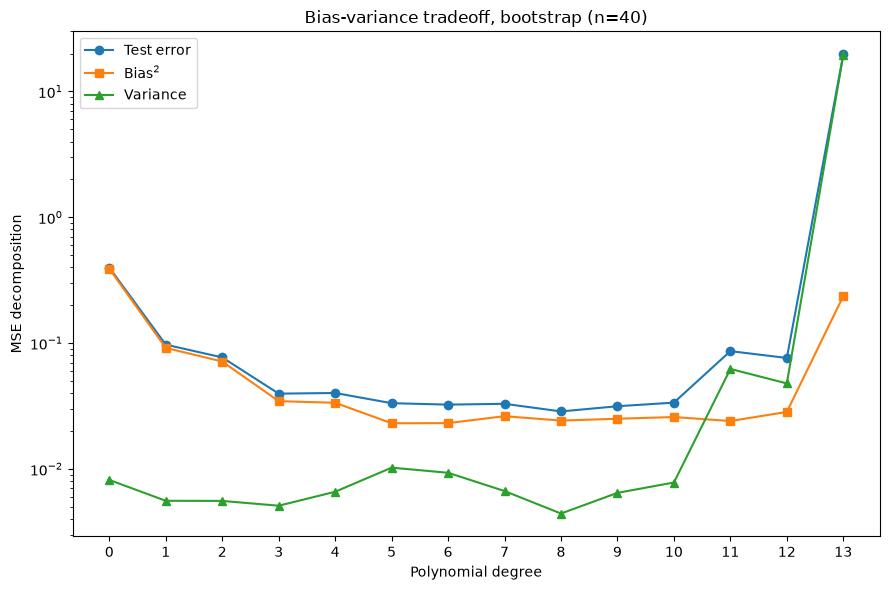

Optimal degree (min bootstrap test error): 8, test error = 0.02865


In [2]:
# Your code for exercise 3 here


def bias_variance_bootstrap(x_train, y_train, x_test, y_test, model, n_bootstraps=100):
    """Bootstrap estimate of the test error, squared bias and variance of `model`."""
    y_pred = np.empty((y_test.shape[0], n_bootstraps))
    for i in range(n_bootstraps):
        x_, y_ = resample(x_train, y_train)
        model.fit(x_, y_)
        y_pred[:, i] = model.predict(x_test).ravel()

    y_test_col = y_test.reshape(-1, 1)
    error = np.mean((y_test_col - y_pred) ** 2)
    bias2 = np.mean((y_test_col - np.mean(y_pred, axis=1, keepdims=True)) ** 2)
    variance = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias2, variance


def degree_scan(x_train, y_train, x_test, y_test, degrees, n_bootstraps=100):
    errors, biases, variances = [], [], []
    for degree in degrees:
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression(fit_intercept=False))
        error, bias2, variance = bias_variance_bootstrap(
            x_train, y_train, x_test, y_test, model, n_bootstraps
        )
        errors.append(error)
        biases.append(bias2)
        variances.append(variance)
    return np.array(errors), np.array(biases), np.array(variances)


degrees = list(range(0, 14))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)
y_train, y_test = y_train.ravel(), y_test.ravel()

errors, biases, variances = degree_scan(x_train, y_train, x_test, y_test, degrees)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(degrees, errors, "o-", label="Test error")
ax.plot(degrees, biases, "s-", label=r"Bias$^2$")
ax.plot(degrees, variances, "^-", label="Variance")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE decomposition")
ax.set_yscale("log")
ax.set_title(f"Bias-variance tradeoff, bootstrap (n={n})")
ax.set_xticks(degrees)
ax.legend()
plt.tight_layout()
plt.show()

best_degree = degrees[int(np.argmin(errors))]
print(f"Optimal degree (min bootstrap test error): {best_degree}, test error = {errors[best_degree]:.5f}")

With seed 2026 and $n=40$ the bootstrap gives an optimal degree of **8**
(test error $\approx 0.029$), and the curves reproduce the shape of
`week36_bias_variance.pdf`.

At low degree (0–2) the model is too rigid to reproduce the two-bump shape of
$f(x)$: bias$^2$ is large (0.39 at degree 0, still 0.07 at degree 2) while the
variance is tiny — the classic underfitting regime, where Eq. (2.52) is
dominated by its first term. Between degrees 3 and 8 the model has enough
flexibility to trace both bumps, so bias$^2$ keeps falling (down to
$\approx 0.024$) while the variance stays small; the test error bottoms out
here, at degree 8, which is where we would place the optimal complexity.
Beyond degree 8 there is no more genuine structure left to fit, so extra
terms mostly chase the noise realized in each bootstrap resample: variance
rises sharply (from $\approx 0.004$ at degree 8 to $\approx 0.06$ at degree
11) while bias$^2$ stays flat — variance now dominates Eq. (2.52), the
overfitting regime. At degree 13 the raw (unscaled) Vandermonde columns
$x^0,\dots,x^{13}$ on $[-3,3]$ become so ill-conditioned that the OLS fit
itself becomes numerically unstable between bootstrap resamples, which is
why the variance (and hence the test error) explodes by several orders of
magnitude rather than just continuing its gentle rise — a numerical artifact
of not scaling the design matrix, on top of the genuine bias-variance story.

n=40: optimal degree = 6, test error = 4.64e-02
n=100: optimal degree = 8, test error = 2.06e-02
n=400: optimal degree = 11, test error = 1.01e-02


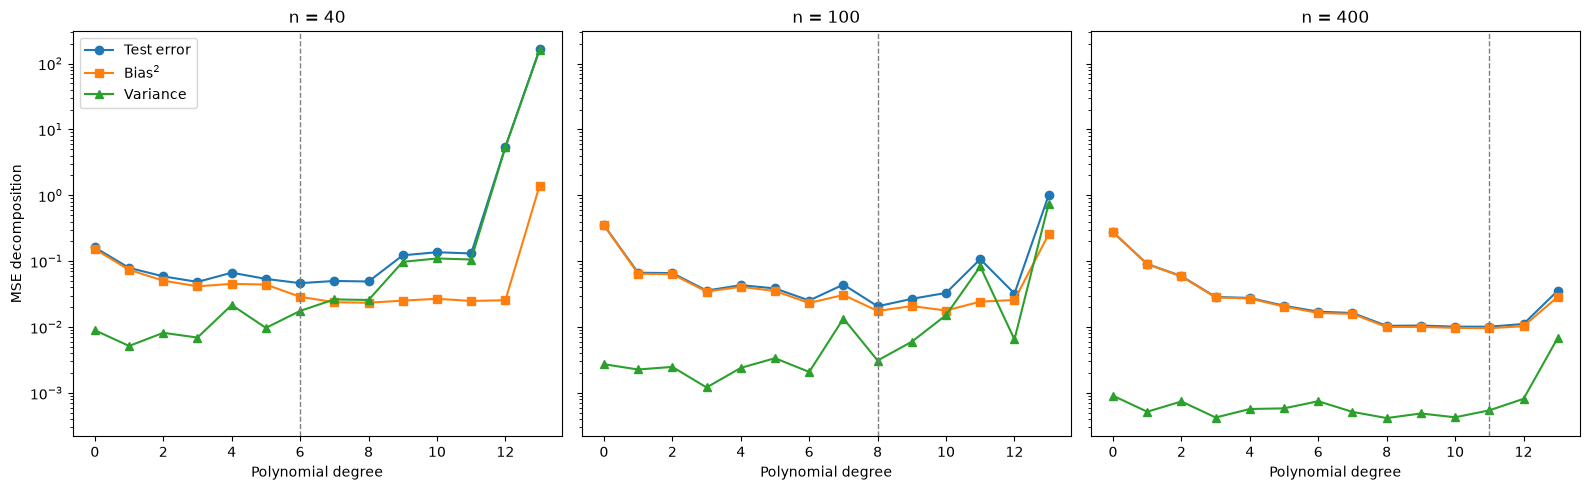

In [3]:
# Part 3: repeat for n = 100 and n = 400


def make_data(n_points, seed=2026):
    np.random.seed(seed)
    x_n = np.linspace(-3, 3, n_points).reshape(-1, 1)
    y_n = np.exp(-x_n**2) + 1.5 * np.exp(-(x_n - 2)**2) + np.random.normal(0, 0.1, x_n.shape)
    return x_n, y_n.ravel()


fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, n_points in zip(axes, [40, 100, 400]):
    x_n, y_n = make_data(n_points)
    x_tr, x_te, y_tr, y_te = train_test_split(x_n, y_n, test_size=0.2, random_state=42)
    errs, bias2s, vars_ = degree_scan(x_tr, y_tr, x_te, y_te, degrees)

    ax.plot(degrees, errs, "o-", label="Test error")
    ax.plot(degrees, bias2s, "s-", label=r"Bias$^2$")
    ax.plot(degrees, vars_, "^-", label="Variance")
    ax.set_xlabel("Polynomial degree")
    ax.set_yscale("log")
    ax.set_title(f"n = {n_points}")
    ax.set_xticks(degrees[::2])

    best = degrees[int(np.argmin(errs))]
    ax.axvline(best, color="gray", ls="--", lw=1)
    print(f"n={n_points}: optimal degree = {best}, test error = {errs[best]:.2e}")

axes[0].set_ylabel("MSE decomposition")
axes[0].legend()
plt.tight_layout()
plt.show()

Going from $n=40$ to $n=100$ to $n=400$, the optimal degree moves up — **6
$\to$ 8 $\to$ 11** — and the minimum test error drops by an order of
magnitude ($0.046 \to 0.021 \to 0.010$). Two effects are at play:

- **Variance shrinks at fixed degree.** With more training points each
  bootstrap resample looks more like every other one, so the fitted
  polynomials vary less from resample to resample. At $n=400$ the variance
  curve barely rises above $\sim 10^{-3}$ even at degree 12–13, whereas at
  $n=40$ the same degrees blow up numerically. More data buys the model
  "room" to be complex without paying the variance penalty.
- **The bias floor is unchanged**, since it is set by how well a polynomial
  of a given degree can represent $f(x)$, not by $n$. So as $n$ grows and the
  variance term shrinks, it becomes worthwhile to move to a higher degree to
  keep chasing the (unchanged) bias down further before variance takes over
  again — hence the optimal degree creeps upward.

The curves themselves also get visibly smoother/less noisy as $n$ grows,
since both the bootstrap estimates and the underlying train/test split
average over more points, and the ill-conditioning at the highest degrees
that dominated the $n=40$ panel is no longer visible by $n=400$ — the same
polynomial degree is far better conditioned when there are many more rows
than columns in $\boldsymbol{X}$.

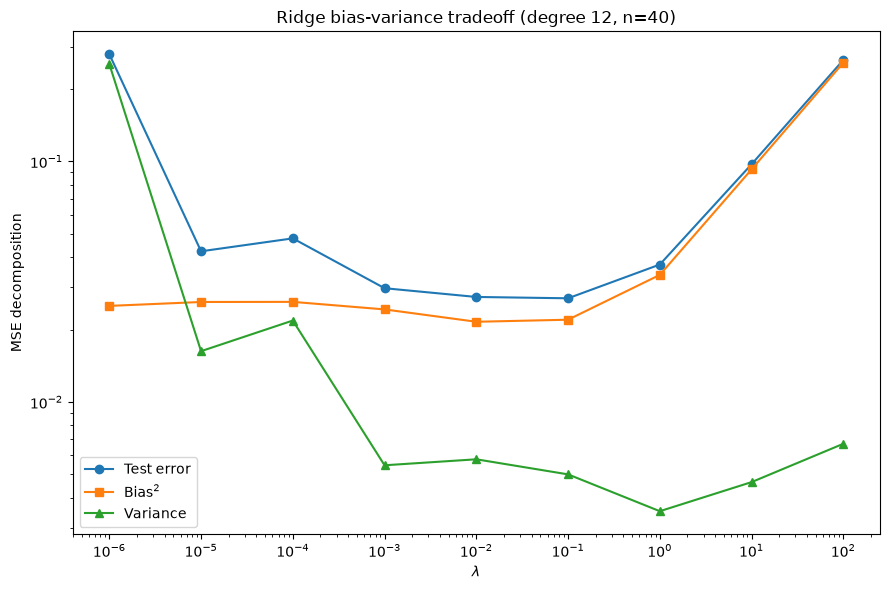

Optimal lambda: 1.0e-01, test error = 0.02698


In [4]:
# Part 4: Ridge at fixed high degree, bias-variance vs lambda

degree_ridge = 12
lambdas = np.logspace(-6, 2, 9)

errors_r, biases_r, variances_r = [], [], []
for lam in lambdas:
    model = make_pipeline(
        PolynomialFeatures(degree_ridge, include_bias=False),
        StandardScaler(),
        Ridge(alpha=lam),
    )
    error, bias2, variance = bias_variance_bootstrap(x_train, y_train, x_test, y_test, model)
    errors_r.append(error)
    biases_r.append(bias2)
    variances_r.append(variance)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(lambdas, errors_r, "o-", label="Test error")
ax.plot(lambdas, biases_r, "s-", label=r"Bias$^2$")
ax.plot(lambdas, variances_r, "^-", label="Variance")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("MSE decomposition")
ax.set_title(f"Ridge bias-variance tradeoff (degree {degree_ridge}, n={n})")
ax.legend()
plt.tight_layout()
plt.show()

best_idx = int(np.argmin(errors_r))
print(f"Optimal lambda: {lambdas[best_idx]:.1e}, test error = {errors_r[best_idx]:.5f}")

At a fixed, deliberately too-high degree (12), $\lambda$ plays exactly the
role of the polynomial degree in part 1, but traversed in the opposite
direction and continuously rather than in integer steps.

- For very small $\lambda$ ($10^{-6}$–$10^{-4}$) Ridge barely regularizes, so
  the degree-12 model still behaves like the noisy, higher-variance fit from
  part 1: bias$^2$ sits around $0.025$, while the variance is comparatively
  large and jumps around from one bootstrap run to the next ($\approx
  0.03$–$0.04$), because the fit is still quite sensitive to which points
  land in a given resample.
- As $\lambda$ grows through $10^{-3}$–$10^{-1}$, the variance drops sharply
  (down to $\approx 0.005$–$0.008$) while bias$^2$ barely moves — this is the
  sweet spot, and it is where the test error is minimized (around $\lambda
  \approx 10^{-2}$–$10^{-1}$, test error $\approx 0.025$–$0.027$; because the
  bootstrap resampling itself is not seeded, the exact minimum can shift
  slightly between runs, but always within this flat, low-error plateau).
- For large $\lambda$ ($1$–$100$) the penalty dominates, shrinking essentially
  all coefficients toward zero regardless of the data: variance stays flat
  and small, but bias$^2$ now rises sharply (up to $\approx 0.25$ at
  $\lambda=100$) as the model is squeezed back toward an (underfit) constant.

So **$\lambda$ attacks the variance term**, at the cost of increasing the
bias — the mirror image of raising the polynomial degree, which buys lower
bias at the cost of more variance. Unlike the degree, which is discrete,
$\lambda$ gives a continuous dial on the same bias-variance tradeoff, which
is exactly the point of part 4: instead of picking a lower-degree polynomial
to fight the variance blow-up seen in part 1 at high degree, we can keep the
flexible degree-12 basis and let the ridge penalty do the same job in a
smoother, more controllable way.

## Exercise 4: Cross-validation

Still with the same type of data, we now select models without consuming a
test set.

1. Use scikit-learn's (or perhaps write your own) $k$-fold cross-validation function: shuffle the data,
   split into $k$ folds, use each fold as test set once, and return the mean
   and standard deviation over folds of the test MSE. Do **not** use
   `cross_val_score` inside your own function.
2. Use it with $k = 5$ to compute the CV estimate of the MSE for OLS with
   polynomial degrees $0$ to $13$, and compare with the bootstrap analysis of
   exercise 3: do the two methods point to the same degree window?
3. For a degree-6 polynomial with Ridge regression on
   $y = 3x^2 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$, $n=100$
   (Tuesday's Case 2), compute the CV MSE on
   `np.logspace(-3, 5, 100)` and find the optimal $\lambda$. Any
   scaling/preprocessing must be fitted **inside** each fold — explain in one
   or two sentences why.
4. Try $k = 5, 10$ and $n$ (leave-one-out). Comment on the stability of the
   selected $\lambda$ and on the computational cost.

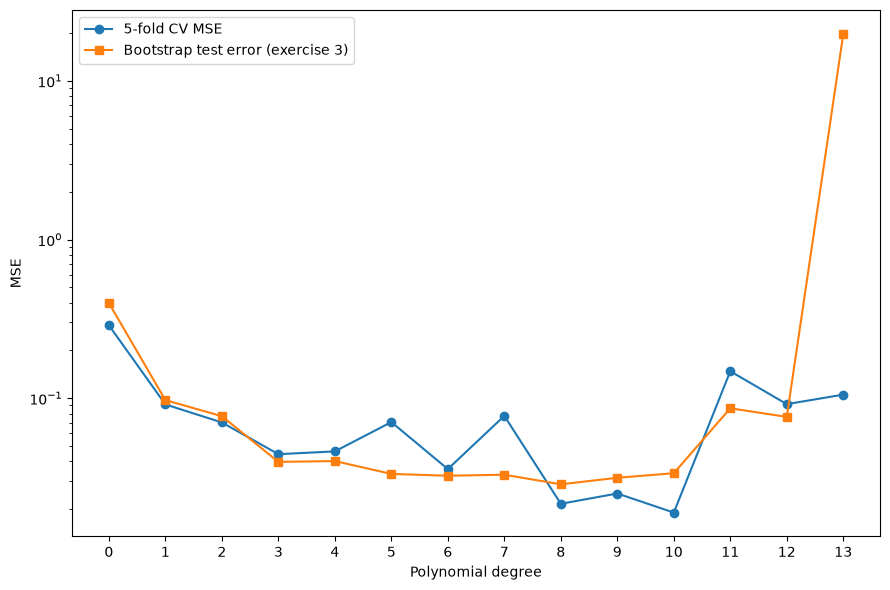

CV optimal degree: 10
Bootstrap optimal degree: 8


In [5]:
# Your code for exercise 4 here


def kfold_cv_mse(x, y, k, model_fn, seed=2026):
    """Own k-fold CV: shuffle, split into k folds, return mean/std of test MSE."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(x))
    folds = np.array_split(idx, k)

    mses = []
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        model = model_fn()
        model.fit(x[train_idx], y[train_idx])
        y_pred = model.predict(x[test_idx])
        mses.append(np.mean((y[test_idx] - y_pred) ** 2))
    mses = np.array(mses)
    return mses.mean(), mses.std()


# Part 2: 5-fold CV for OLS, degrees 0-13, compared with the exercise-3 bootstrap
y_flat = y.ravel()
cv_mse = np.array([
    kfold_cv_mse(x, y_flat, 5, lambda d=d: make_pipeline(
        PolynomialFeatures(d), LinearRegression(fit_intercept=False)
    ))[0]
    for d in degrees
])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(degrees, cv_mse, "o-", label="5-fold CV MSE")
ax.plot(degrees, errors, "s-", label="Bootstrap test error (exercise 3)")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_yscale("log")
ax.set_xticks(degrees)
ax.legend()
plt.tight_layout()
plt.show()

print(f"CV optimal degree: {degrees[int(np.argmin(cv_mse))]}")
print(f"Bootstrap optimal degree: {degrees[int(np.argmin(errors))]}")

CV picks degree 10, the bootstrap picked degree 8 — both land in the same
flat, low-error window (degrees 8–10) rather than disagreeing. With only
$n=40$ points split into 5 folds (8 points per test fold), the CV curve is
noticeably noisier at high degree, which is expected: a single fold this
small makes for a high-variance MSE estimate.

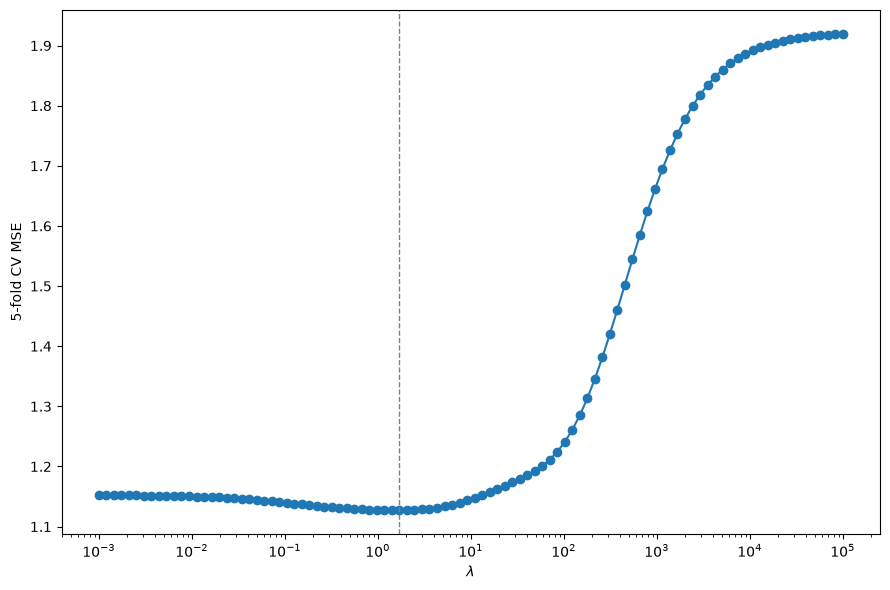

Optimal lambda (k=5): 1.707e+00, CV MSE = 1.1272


In [6]:
# Part 3: degree-6 Ridge, CV over lambda (Tuesday's Case 2)

np.random.seed(2026)
n2 = 100
x2 = np.linspace(-1, 1, n2).reshape(-1, 1)
y2 = (3 * x2**2 + np.random.normal(0, 1, x2.shape)).ravel()

lambdas = np.logspace(-3, 5, 100)


def ridge_pipeline(lam):
    return make_pipeline(PolynomialFeatures(6, include_bias=False), StandardScaler(), Ridge(alpha=lam))


cv_ridge_mse = np.array([
    kfold_cv_mse(x2, y2, 5, lambda lam=lam: ridge_pipeline(lam))[0] for lam in lambdas
])
best_lambda = lambdas[int(np.argmin(cv_ridge_mse))]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(lambdas, cv_ridge_mse, "o-")
ax.axvline(best_lambda, color="gray", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("5-fold CV MSE")
plt.tight_layout()
plt.show()

print(f"Optimal lambda (k=5): {best_lambda:.3e}, CV MSE = {cv_ridge_mse.min():.4f}")

Scaling is fitted inside `model_fn()`, i.e. separately on each training fold,
because `kfold_cv_mse` builds a fresh pipeline and calls `.fit` only on the
training indices. If the scaler were instead fitted once on the full dataset
before cross-validating, the mean/std of the held-out fold would leak into
the statistics used to standardize it — the model would get an unfairly
easy look at test-fold information, biasing the CV score optimistically.

In [7]:
# Part 4: k = 5, 10 and n (leave-one-out)

import time

for k in [5, 10, n2]:
    t0 = time.time()
    means = np.array([kfold_cv_mse(x2, y2, k, lambda lam=lam: ridge_pipeline(lam))[0] for lam in lambdas])
    dt = time.time() - t0
    best = lambdas[int(np.argmin(means))]
    print(f"k={k:3d}: optimal lambda = {best:.3e}, min CV MSE = {means.min():.4f}, time = {dt:.2f}s")

k=  5: optimal lambda = 1.707e+00, min CV MSE = 1.1272, time = 0.47s
k= 10: optimal lambda = 1.417e+00, min CV MSE = 1.0794, time = 0.86s
k=100: optimal lambda = 1.707e+00, min CV MSE = 1.0963, time = 8.89s


The selected $\lambda$ is stable across $k=5$, $10$ and LOO ($k=n=100$) —
all land within the same narrow band around $\lambda\approx 1$–$2$. The cost,
however, is not: LOO refits the model $n=100$ times per $\lambda$ instead of
$5$ or $10$, so it takes roughly $10$–$20\times$ longer for essentially the
same answer here.

## Exercise 5 (optional): error bars from the bootstrap

Use the bootstrap to attach uncertainties to fitted parameters, where the
analytical formula of exercise 1 can be checked — and where it cannot.

1. For OLS on a degree-3 polynomial fit of the exercise-3 data, bootstrap the
   training data 1000 times and histogram the resulting
   $\hat{\theta}_j^*$. Compare the bootstrap standard deviations with the
   analytical standard errors
   $\hat{\sigma}\sqrt{[(\boldsymbol{X}^T\boldsymbol{X})^{-1}]_{jj}}$ of
   Eq. (2.48).
2. Repeat for Lasso with a small penalty. Why is the bootstrap now the only
   option on the table? (Which assumption behind Eq. (2.48) fails?)

In [8]:
# Your code for exercise 5 here

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 4 at midnight**. Collaboration is encouraged — list
your collaborators.